______________________________________
## Credit Card Fraud Detector
______________________________

In [13]:
# Gathering Environment

import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [7]:
# Loading Dataset

df = pd.read_csv('../Data/creditcard.csv')
df.sample(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
200558,133480.0,-0.005342,0.746923,0.219277,-0.587140,0.370413,-0.979116,1.040140,-0.156921,0.022750,...,-0.250045,-0.602122,0.131160,-0.106715,-0.500952,0.148635,0.238514,0.097022,26.99,0
127238,78258.0,1.131678,-0.148501,1.149198,1.156443,-0.830485,0.297663,-0.722131,0.303604,0.772327,...,-0.041211,0.013723,-0.049116,-0.013078,0.402886,-0.403474,0.063021,0.023218,9.99,0
261491,160041.0,-0.564018,0.880369,0.688034,-0.558182,0.716475,-0.895190,1.180756,-0.362450,-0.532268,...,0.375135,1.169226,-0.471687,0.003235,0.319068,0.571420,-0.064103,0.134312,29.00,0
198693,132612.0,0.753441,0.923188,-0.718350,1.196061,0.417847,-0.160122,0.342986,-0.037489,-0.461748,...,-0.289059,-0.596026,0.263582,0.703722,-0.592973,0.535962,0.025093,-0.092376,16.99,0
41938,40891.0,-1.007656,0.113883,0.974746,2.968336,1.492045,-0.510013,0.498016,-0.011190,-2.084051,...,0.289984,0.385032,0.178395,0.013220,-0.153324,0.225947,0.069548,0.169818,93.49,0


In [8]:
X = df.drop(columns='Class')
Y = df['Class']

In [9]:
X_Train,X_Test,Y_Train,Y_Test = train_test_split(X,Y,random_state=42,test_size=0.2)

In [10]:
rf = RandomForestClassifier(n_estimators=50,random_state=42)
rf.fit(X_Train,Y_Train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [11]:
Y_pred = rf.predict(X_Test)

In [12]:
accuracy = accuracy_score(Y_Test, Y_pred)
print(accuracy)

0.9995435553526912


<Figure size 600x500 with 0 Axes>

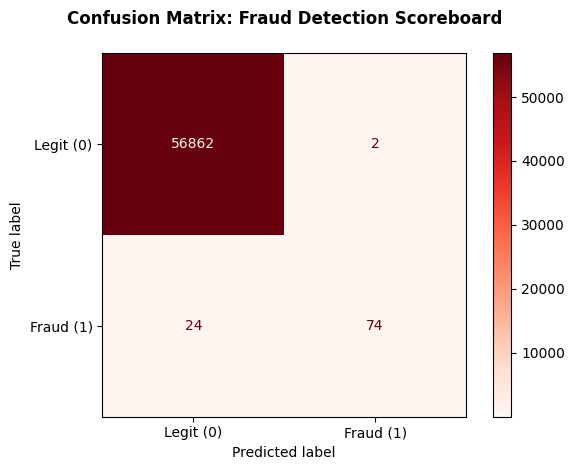

In [15]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(Y_Test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit (0)', 'Fraud (1)'])

# Using 'Reds' or 'Blues' to emphasize the contrast
disp.plot(cmap='Reds', values_format='d')  
plt.title('Confusion Matrix: Fraud Detection Scoreboard\n', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()